***Milestone 1: Data Collection***

In [1]:
import requests
import pandas as pd

# Your TMDb API key
API_KEY = '574e4ada8683a5021f82a4b86dc5ad05'

def fetch_movies(page):
    """Fetches a page of movies from TMDb API."""
    url = f'https://api.themoviedb.org/3/discover/movie?api_key={API_KEY}&language=en-US&sort_by=popularity.desc&page={page}'
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error fetching page {page}: {response.status_code}")
        return None

def fetch_movie_details(movie_id):
    """Fetches detailed information about a specific movie."""
    url = f'https://api.themoviedb.org/3/movie/{movie_id}?api_key={API_KEY}&language=en-US'
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error fetching movie ID {movie_id}: {response.status_code}")
        return None

# List to hold movie data
movie_data = []

# Fetch data for 200 pages (assuming 10 movies per page)
for page in range(1, 201):  # Adjust range as needed for more/less data
    print(f"Fetching page {page}...")
    data = fetch_movies(page)
    if data:
        for movie in data['results']:
            movie_details = fetch_movie_details(movie['id'])
            if movie_details:
                movie_data.append({
                    'Title': movie.get('title'),
                    'Genre(s)': ', '.join([genre['name'] for genre in movie_details.get('genres', [])]),
                    'Release Year': movie.get('release_date', '').split('-')[0],
                    'IMDb Rating': movie.get('vote_average'),
                    'User Votes': movie.get('vote_count'),
                    'Description': movie.get('overview'),
                    'Poster URL': f"https://image.tmdb.org/t/p/w500{movie.get('poster_path')}" if movie.get('poster_path') else None
                })

# Save to CSV
df = pd.DataFrame(movie_data)
df.to_csv('movies_dataset.csv', index=False)
print("Data saved to movies_dataset.csv")

Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...
Fetching page 31...
Fetching page 32...
Fetching page 33...
Fetching page 34...
Fetching page 35...
Fetching page 36...
Fetching page 37...
Fetching page 38...
Fetching page 39...
Fetching page 40...
Fetching page 41...
Fetching page 42...
Fetching page 43...
Fetching page 44...
Fetching page 45...
Fetching page 46...
Fetching page 47...
Fetching page 48...
Fetching page 49...
Fetching page 50...
Fetching 

***Milestone 2: Data Cleaning and Preprocessing***

In [159]:
import pandas as pd
path= "C:/Users/nurai/OneDrive/Desktop/movies_dataset.xls"
df = pd.read_csv(path)
print(df.isnull().sum())

print(df.dtypes)

Title            0
Genre(s)        12
Release Year    12
IMDb Rating      0
User Votes       0
Description     25
Poster URL       4
dtype: int64
Title            object
Genre(s)         object
Release Year    float64
IMDb Rating     float64
User Votes        int64
Description      object
Poster URL       object
dtype: object


In [161]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Check for missing values and data types
print(df.isnull().sum())
print(df.dtypes)

# Handle missing values
df['Genre'] = df['Genre(s)'].str.split(',').str[0]
df['IMDb Rating'] =df['IMDb Rating']
df['User Votes'] =df['User Votes']
df['Genre(s)'] = df['Genre(s)'].fillna(df['Genre(s)'].mode()[0])
df['Release Year'] = pd.to_numeric(df['Release Year'], errors='coerce')  # Convert to numeric
df['Release Year'] = df['Release Year'].fillna(df['Release Year'].median())
df['Description'] = df['Description'].fillna('No description')
df['Poster URL'] = df['Poster URL'].dropna()

# Normalize numerical features
scaler = MinMaxScaler()
df['IMDb Rating Norm'] = scaler.fit_transform(df[['IMDb Rating']])
df['User Votes Norm'] = scaler.fit_transform(df[['User Votes']])
df['Release Year Norm'] = scaler.fit_transform(df[['Release Year']])


# Categorical encoding for genres
encoder = LabelEncoder()
df['Genre_transformed'] = encoder.fit_transform(df['Genre'])  # Encode primary genre

# Remove duplicate entries
df = df.drop_duplicates(subset=['Title'])

# Save cleaned data to CSV
df.to_csv('cleaned_movies_dataset.csv', index=False)
print("Cleaned dataset saved to cleaned_movies_dataset.csv.")

Title            0
Genre(s)        12
Release Year    12
IMDb Rating      0
User Votes       0
Description     25
Poster URL       4
dtype: int64
Title            object
Genre(s)         object
Release Year    float64
IMDb Rating     float64
User Votes        int64
Description      object
Poster URL       object
dtype: object
Cleaned dataset saved to cleaned_movies_dataset.csv.


In [163]:
df

,Title,Genre(s),Release Year,IMDb Rating,User Votes,Description,Poster URL,Genre,IMDb Rating Norm,User Votes Norm,Release Year Norm,Genre_transformed
0,Venom: The Last Dance,"Action, Science Fiction, Adventure",2024.0,6.600,1106,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...,Action,0.6600,0.030190,0.971698,0
1,Moana 2,"Animation, Adventure, Family, Comedy",2024.0,6.900,419,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...,Animation,0.6900,0.011437,0.971698,2
2,Elevation,"Action, Science Fiction, Thriller",2024.0,6.400,126,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...,Action,0.6400,0.003439,0.971698,0
3,Absolution,"Action, Crime, Thriller",2024.0,6.100,120,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...,Action,0.6100,0.003276,0.971698,0
4,Watchmen: Chapter II,"Animation, Mystery, Science Fiction, Action",2024.0,7.700,41,Suspicious of the events ensnaring their forme...,https://image.tmdb.org/t/p/w500/4rBObJFpiWJOG7...,Animation,0.7700,0.001119,0.971698,2
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,The Frighteners,"Horror, Comedy",1996.0,6.900,1530,"Once an architect, Frank Bannister now passes ...",https://image.tmdb.org/t/p/w500/2ZwWDOoU1yy9qy...,Horror,0.6900,0.041763,0.707547,10
3996,Pieces of a Woman,Drama,2020.0,7.026,1208,When a young mother's home birth ends in unfat...,https://image.tmdb.org/t/p/w500/OgUfLlhfBFx5BP...,Drama,0.7026,0.032974,0.933962,6
3997,22 July,"Crime, Drama, History, Thriller",2018.0,7.100,1177,"On 22 July 2011, neo-Nazi terrorist Anders Beh...",https://image.tmdb.org/t/p/w500/rd940KzuIZwbdO...,Crime,0.7100,0.032128,0.915094,4
3998,Fantomas,"Comedy, Crime, Adventure",1964.0,6.800,722,Fantômas is a man of many disguises. He uses m...,https://image.tmdb.org/t/p/w500/tw1dTJgyCb9ZEp...,Comedy,0.6800,0.019708,0.405660,3


***Milestone 3: Exploratory Data Analysis (EDA)***

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('cleaned_movies_dataset.csv')

# Inspect the dataset
print(df.head())
print(df.info())
print(df.describe())

                   Title                                     Genre(s)  \
0  Venom: The Last Dance           Action, Science Fiction, Adventure   
1                Moana 2         Animation, Adventure, Family, Comedy   
2              Elevation            Action, Science Fiction, Thriller   
3             Absolution                      Action, Crime, Thriller   
4   Watchmen: Chapter II  Animation, Mystery, Science Fiction, Action   

   Release Year  IMDb Rating  User Votes  \
0        2024.0          6.6        1106   
1        2024.0          6.9         419   
2        2024.0          6.4         126   
3        2024.0          6.1         120   
4        2024.0          7.7          41   

                                         Description  \
0  Eddie and Venom are on the run. Hunted by both...   
1  After receiving an unexpected call from her wa...   
2  A single father and two women venture from the...   
3  An aging ex-boxer gangster working as muscle f...   
4  Suspicious of

In [168]:
# Statistical summary for numerical features
print("Mean IMDb Rating:", df['IMDb Rating'].mean())
print("Median IMDb Rating:", df['IMDb Rating'].median())
print("Mean Number of Votes:", df['User Votes'].mean())
print("Median Number of Votes:", df['User Votes'].median())
print(df.describe())

Mean IMDb Rating: 6.570627220480669
Median IMDb Rating: 6.7
Mean Number of Votes: 3207.3194879832813
Median Number of Votes: 1444.0
       Release Year  IMDb Rating    User Votes  IMDb Rating Norm  \
count   3828.000000  3828.000000   3828.000000       3828.000000   
mean    2010.861285     6.570627   3207.319488          0.657063   
std       14.404650     1.283239   4541.870911          0.128324   
min     1921.000000     0.000000      0.000000          0.000000   
25%     2005.000000     6.124750    216.750000          0.612475   
50%     2015.000000     6.700000   1444.000000          0.670000   
75%     2022.000000     7.300000   4304.500000          0.730000   
max     2027.000000    10.000000  36635.000000          1.000000   

       User Votes Norm  Release Year Norm  Genre_transformed  
count      3828.000000        3828.000000        3828.000000  
mean          0.087548           0.847748           5.619122  
std           0.123976           0.135893           5.015645  
min

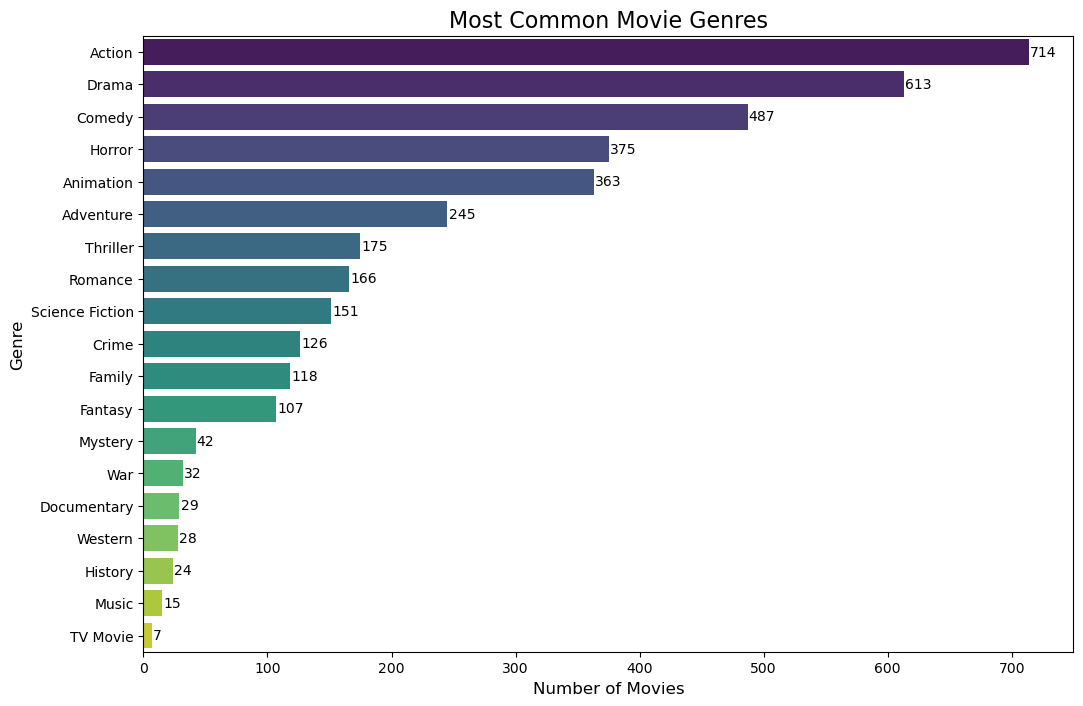

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart of the most common genres
plt.figure(figsize=(12, 8))
colors = sns.color_palette('viridis', len(df['Genre'].value_counts()))  # Generate unique colors

# Create the bar plot with `hue` explicitly set
sns.barplot(
    x=df['Genre'].value_counts().values,
    y=df['Genre'].value_counts().index,
    hue=df['Genre'].value_counts().index,  # Use genres as the hue
    dodge=False,  # Avoid splitting bars
    palette=colors,
    legend=False  # No legend needed for this case
)

# Add labels to each bar
for i, count in enumerate(df['Genre'].value_counts().values):
    plt.text(count + 1, i, str(count), va='center', fontsize=10, color='black')  # Add count next to each bar

# Customize the plot
plt.title("Most Common Movie Genres", fontsize=16)
plt.xlabel("Number of Movies", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.show()

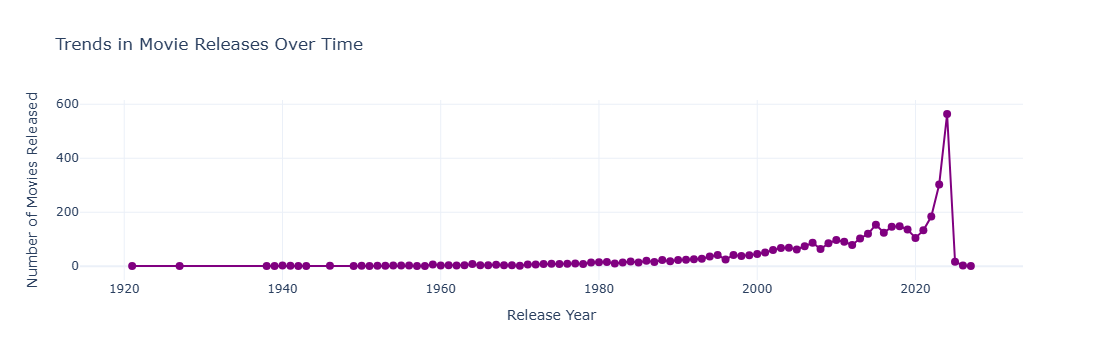

In [171]:
import pandas as pd
import plotly.graph_objects as go

# Filter valid release years
df['Release Year'] = pd.to_numeric(df['Release Year'], errors='coerce')  # Ensure numeric values
valid_years = df['Release Year'].dropna().astype(int)  # Remove NaNs and convert to integer

# Group movies by release year
movies_per_year = valid_years.value_counts().sort_index()

# Create the interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=movies_per_year.index,
    y=movies_per_year.values,
    mode='lines+markers',  # Line plot with markers
    hovertemplate="Year: %{x}<br>Movies Released: %{y}",  # Hover template
    line=dict(color='purple', width=2),  # Line style
    marker=dict(size=8)  # Marker style
))

# Customize layout
fig.update_layout(
    title="Trends in Movie Releases Over Time",
    xaxis_title="Release Year",
    yaxis_title="Number of Movies Released",
    template="plotly_white"
)

# Show the plot
fig.show()

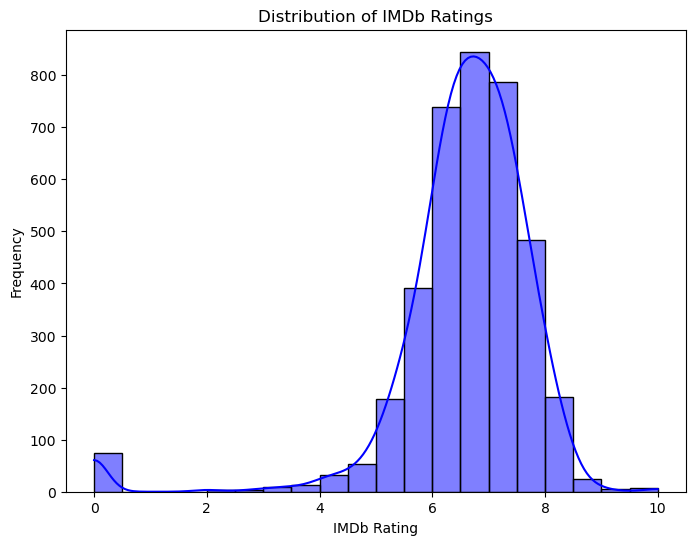

In [173]:
# Histogram for IMDb ratings
plt.figure(figsize=(8, 6))
sns.histplot(df['IMDb Rating'], kde=True, bins=20, color='blue')
plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Frequency")
plt.show()

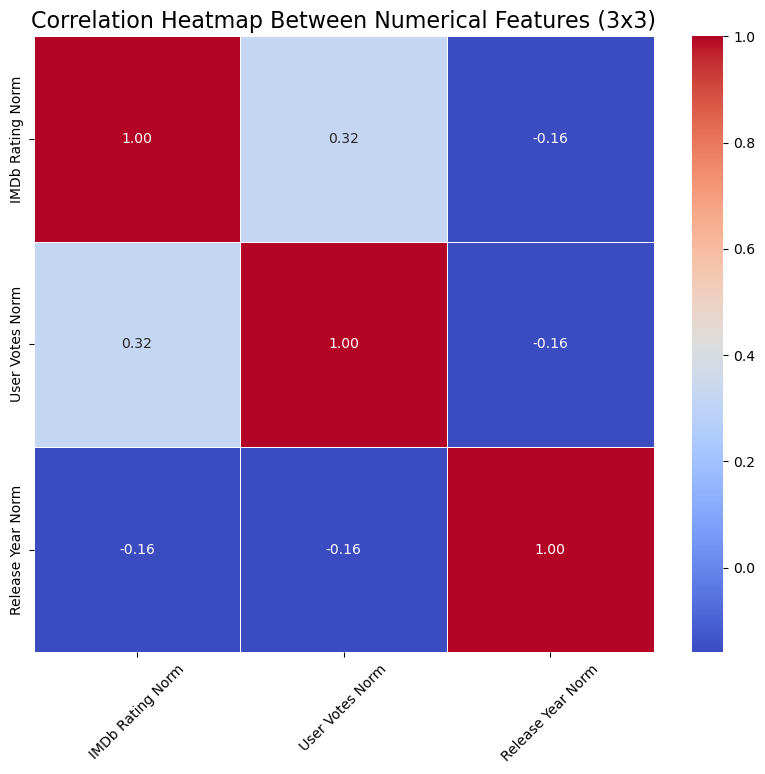

In [175]:
correlation_matrix = df[['IMDb Rating Norm', 'User Votes Norm', 'Release Year Norm']].corr()

# Correlation heatmap
df['Release Year Norm'] = scaler.fit_transform(df[['Release Year']])
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap Between Numerical Features (3x3)", fontsize=16)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

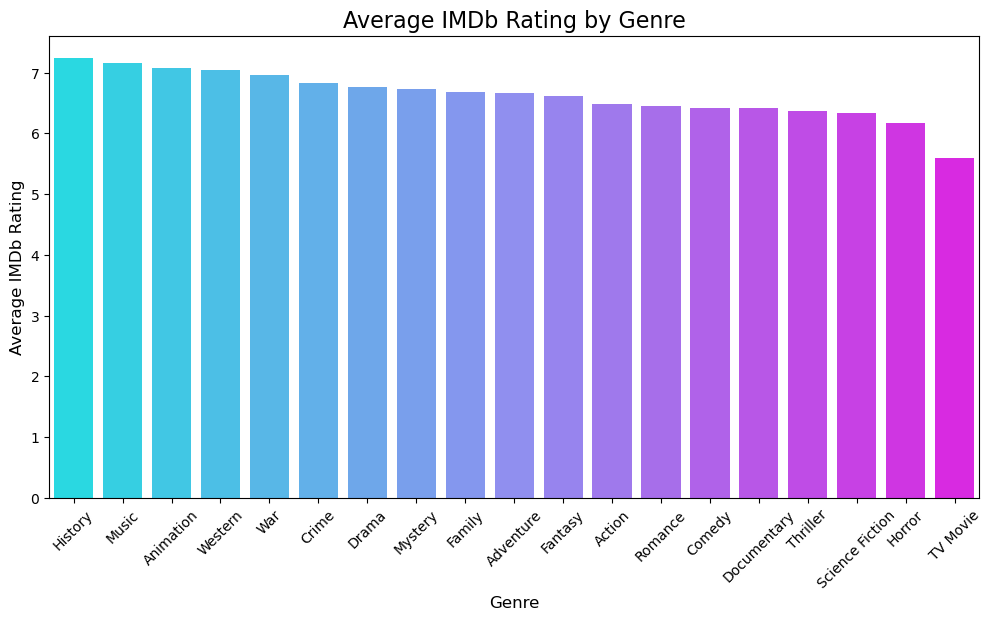

In [178]:
# Average IMDb Rating per genre
avg_rating_per_genre = df.groupby('Genre')['IMDb Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=avg_rating_per_genre.index,
    y=avg_rating_per_genre.values,
    palette='cool',
    hue=avg_rating_per_genre.index,  # Explicitly assign x variable to hue
    dodge=False,  # Avoid splitting bars
    legend=False  # Disable legend for this case
)
plt.title("Average IMDb Rating by Genre", fontsize=16)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Average IMDb Rating", fontsize=12)
plt.xticks(rotation=45)
plt.show()

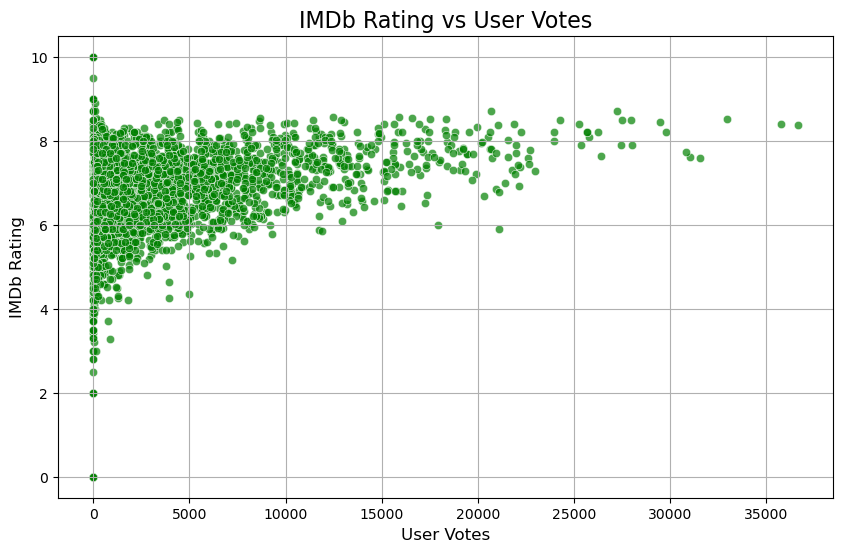

In [180]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='User Votes', y='IMDb Rating', data=df, alpha=0.7, color='green')
plt.title("IMDb Rating vs User Votes", fontsize=16)
plt.xlabel("User Votes", fontsize=12)
plt.ylabel("IMDb Rating", fontsize=12)
plt.grid(True)
plt.show()

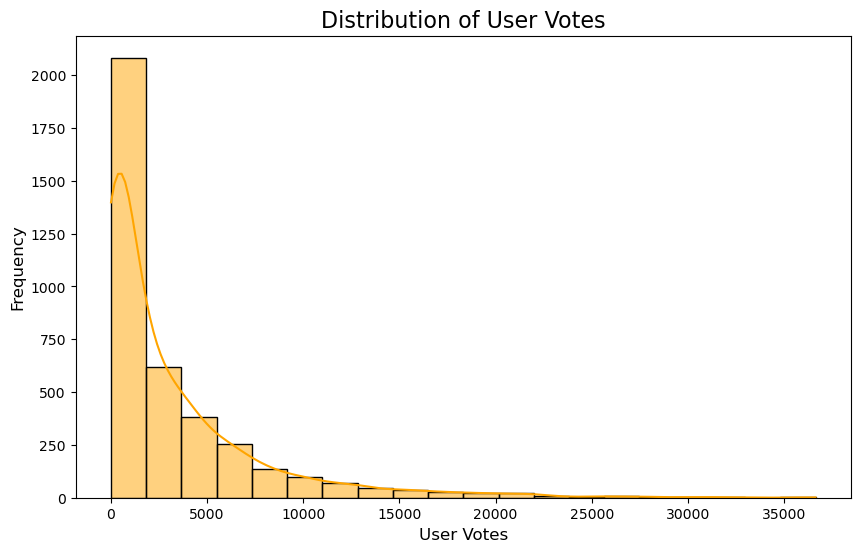

In [182]:
plt.figure(figsize=(10, 6))
sns.histplot(df['User Votes'], kde=True, bins=20, color='orange')
plt.title("Distribution of User Votes", fontsize=16)
plt.xlabel("User Votes", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

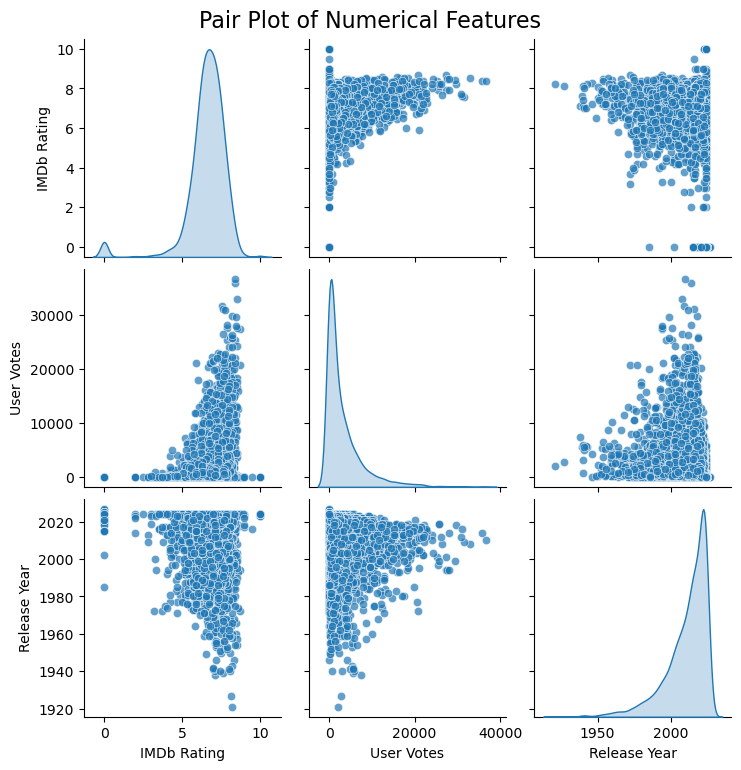

In [184]:
sns.pairplot(df[['IMDb Rating', 'User Votes', 'Release Year']], diag_kind='kde', plot_kws={'alpha':0.7})
plt.suptitle("Pair Plot of Numerical Features", y=1.02, fontsize=16)
plt.show()

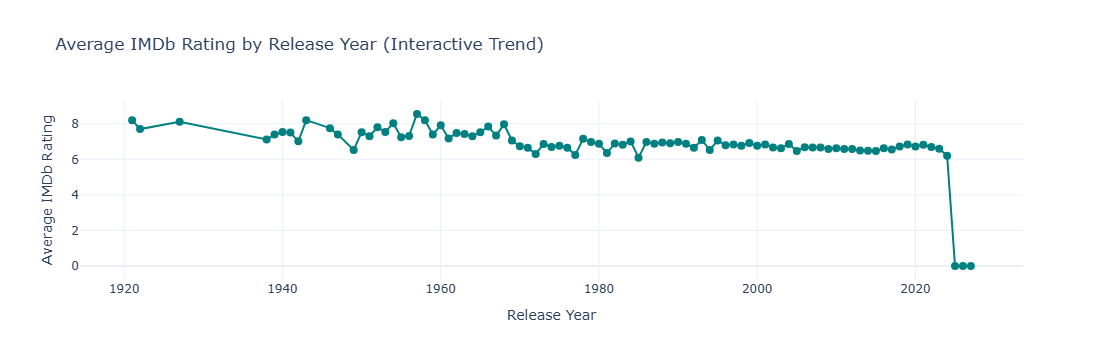

In [185]:
import plotly.graph_objects as go

# Data: Average IMDb Rating by Release Year
ratings_by_year = movies_df.groupby('Release Year')['IMDb Rating'].mean()

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ratings_by_year.index,
    y=ratings_by_year.values,
    mode='lines+markers',  # Line plot with markers
    hovertemplate="Year: %{x}<br>Average IMDb Rating: %{y:.2f}",
    line=dict(color='teal', width=2),
    marker=dict(size=8)
))

# Customize layout
fig.update_layout(
    title="Average IMDb Rating by Release Year (Interactive Trend)",
    xaxis_title="Release Year",
    yaxis_title="Average IMDb Rating",
    template="plotly_white"
)

# Show plot
fig.show()

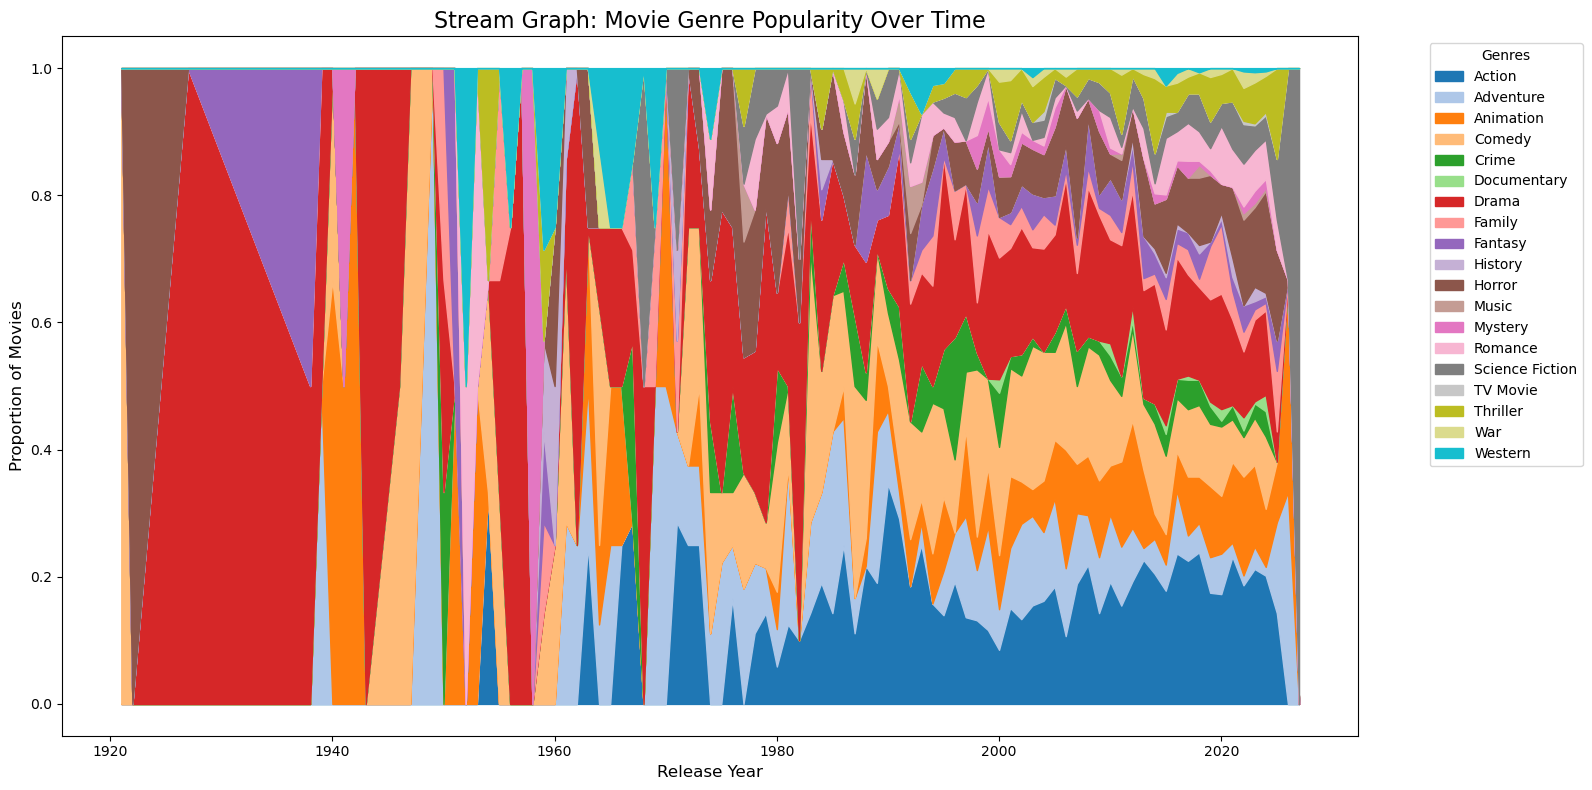

In [186]:
# Create a Stream Graph: Movie Genres Over Years
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_hex

# Prepare the data
movies_df['Primary Genre'] = movies_df['Genre(s)'].str.split(',').str[0]
genre_year_data = movies_df.groupby(['Release Year', 'Primary Genre']).size().unstack(fill_value=0)

# Normalize data for stream graph
genre_year_data_norm = genre_year_data.div(genre_year_data.sum(axis=1), axis=0)

# Generate color palette
colors = sns.color_palette('tab20', len(genre_year_data.columns))
hex_colors = [to_hex(color) for color in colors]

# Create the stream graph
plt.figure(figsize=(16, 8))
for i, genre in enumerate(genre_year_data_norm.columns):
    plt.fill_between(
        genre_year_data_norm.index,
        genre_year_data_norm.iloc[:, :i].sum(axis=1),
        genre_year_data_norm.iloc[:, :i + 1].sum(axis=1),
        color=hex_colors[i],
        label=genre
    )

# Add labels and title
plt.title("Stream Graph: Movie Genre Popularity Over Time", fontsize=16)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Proportion of Movies", fontsize=12)
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

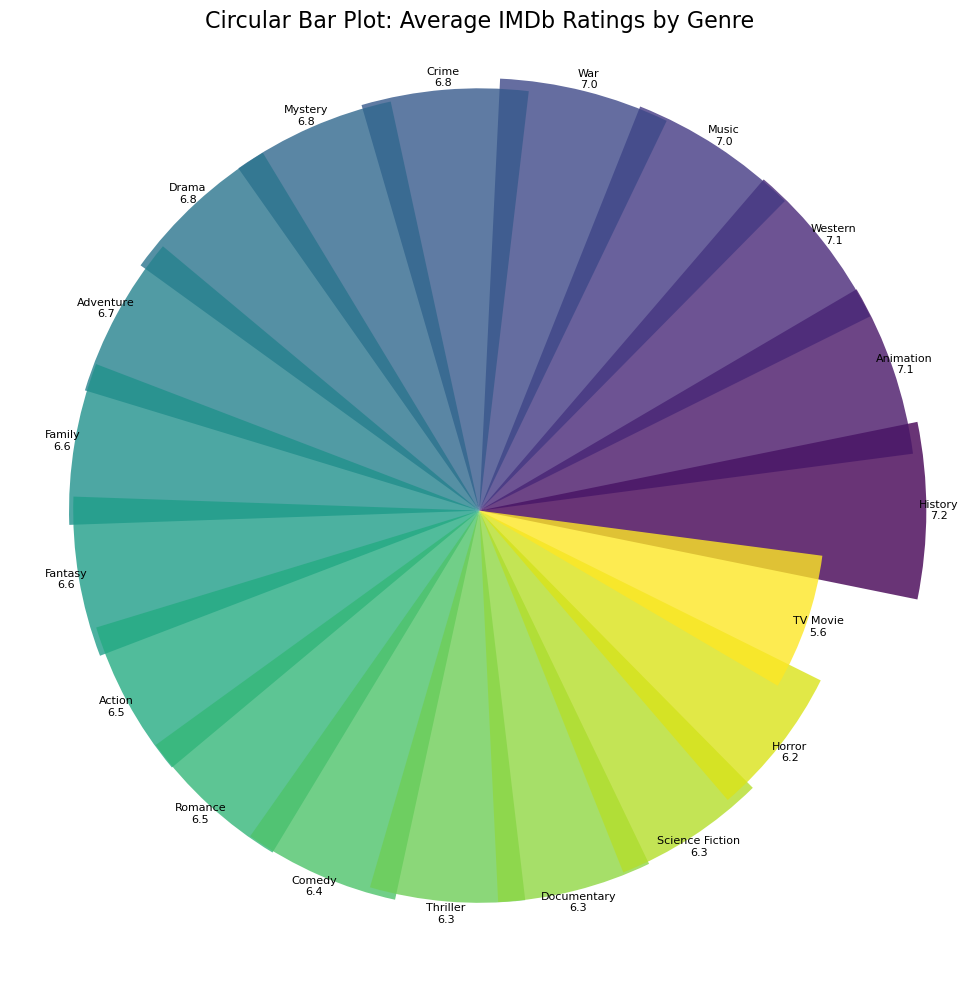

In [187]:
# Visualization: Circular Bar Plot for Average IMDb Ratings by Genre

import numpy as np
import matplotlib.pyplot as plt

# Prepare data
genre_avg_rating = movies_df.groupby('Primary Genre')['IMDb Rating'].mean().sort_values(ascending=False)
genres = genre_avg_rating.index
ratings = genre_avg_rating.values

# Calculate angles for bars
angles = np.linspace(0, 2 * np.pi, len(genres), endpoint=False).tolist()

# Repeat the first value to close the circular plot
ratings = np.concatenate((ratings, [ratings[0]]))
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
ax.bar(angles[:-1], ratings[:-1], width=0.4, color=plt.cm.viridis(np.linspace(0, 1, len(genres))), align='center', alpha=0.8)

# Add labels
for i, (angle, rating) in enumerate(zip(angles[:-1], ratings[:-1])):
    ax.text(angle, rating + 0.2, f"{genres[i]}\n{rating:.1f}", ha='center', va='center', fontsize=8, color='black')

# Customize plot
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Circular Bar Plot: Average IMDb Ratings by Genre", va='bottom', fontsize=16)
ax.spines['polar'].set_visible(False)

plt.tight_layout()
plt.show()

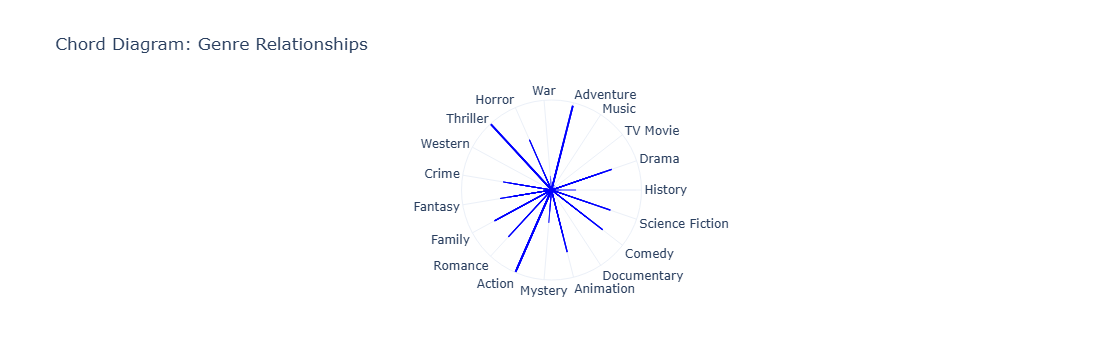

In [188]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Prepare data
# Create a co-occurrence matrix for genres
genres_split = movies_df['Genre(s)'].dropna().str.split(', ')
unique_genres = set([genre for genres in genres_split for genre in genres])
genre_list = list(unique_genres)

co_occurrence = pd.DataFrame(0, index=genre_list, columns=genre_list)

# Fill co-occurrence matrix
for genres in genres_split:
    for genre1 in genres:
        for genre2 in genres:
            co_occurrence.at[genre1, genre2] += 1

# Normalize the matrix for better visualization
co_occurrence_norm = co_occurrence.div(co_occurrence.max().max()).fillna(0)

# Create the chord diagram
fig = go.Figure()

for i, genre1 in enumerate(genre_list):
    for j, genre2 in enumerate(genre_list):
        if i != j:
            fig.add_trace(go.Scatterpolar(
                r=[co_occurrence_norm.iloc[i, j], 0, co_occurrence_norm.iloc[j, i]],
                theta=[genre1, genre1, genre2],
                mode='lines',
                line=dict(width=co_occurrence_norm.iloc[i, j] * 5, color='blue'),
                hoverinfo='text',
                text=f"Co-occurrence: {co_occurrence.iloc[i, j]}"
            ))

# Customize layout
fig.update_layout(
    title="Chord Diagram: Genre Relationships",
    polar=dict(
        radialaxis=dict(visible=False),
    ),
    showlegend=False,
    template="plotly_white"
)

# Show the diagram
fig.show()

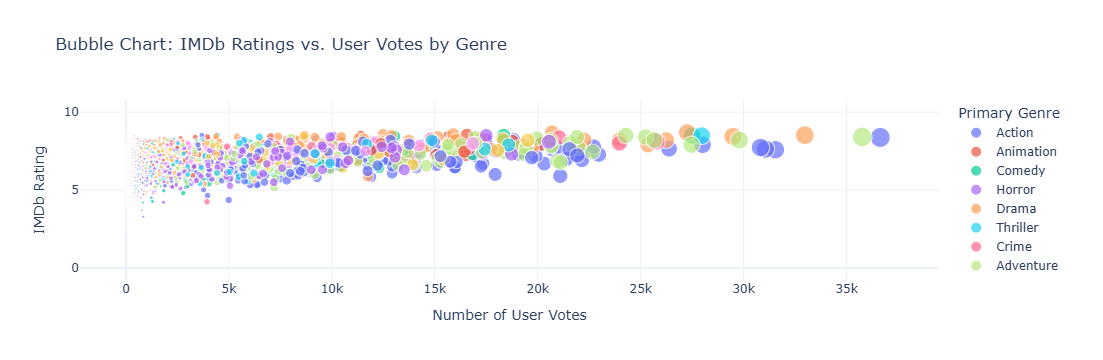

In [189]:
import plotly.express as px

# Create a bubble chart
fig = px.scatter(
    movies_df,
    x="User Votes",
    y="IMDb Rating",
    size="User Votes",
    color="Primary Genre",
    hover_name="Title",
    title="Bubble Chart: IMDb Ratings vs. User Votes by Genre",
    labels={"User Votes": "Number of User Votes", "IMDb Rating": "IMDb Rating"},
    template="plotly_white"
)

# Show the plot
fig.show()

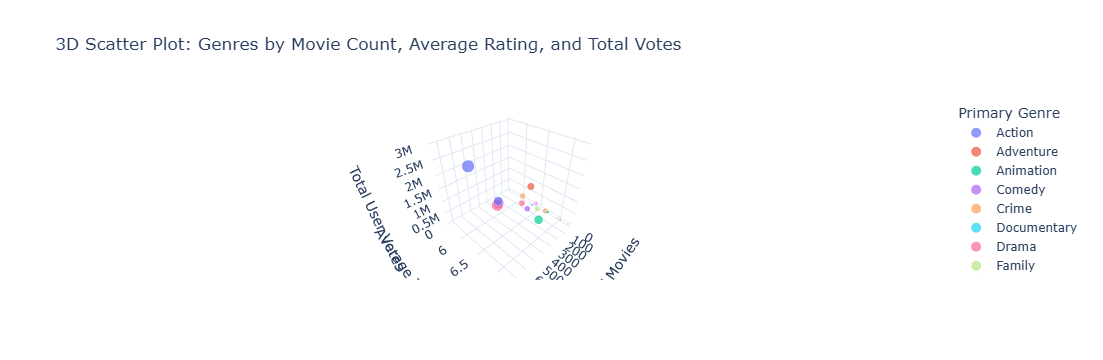

In [190]:
import plotly.express as px
import pandas as pd

# Prepare data for 3D plot
movies_df['Primary Genre'] = movies_df['Genre(s)'].str.split(',').str[0]
genre_data = movies_df.groupby('Primary Genre').agg(
    Average_Rating=('IMDb Rating', 'mean'),
    Total_Votes=('User Votes', 'sum'),
    Movie_Count=('Title', 'count')
).reset_index()

# Create a dynamic 3D scatter plot
fig = px.scatter_3d(
    genre_data,
    x='Movie_Count',
    y='Average_Rating',
    z='Total_Votes',
    color='Primary Genre',
    size='Movie_Count',
    hover_name='Primary Genre',
    title="3D Scatter Plot: Genres by Movie Count, Average Rating, and Total Votes",
    labels={
        'Movie_Count': 'Number of Movies',
        'Average_Rating': 'Average IMDb Rating',
        'Total_Votes': 'Total User Votes'
    },
    template="plotly_white"
)

# Customize layout
fig.update_layout(
    scene=dict(
        xaxis=dict(title="Number of Movies"),
        yaxis=dict(title="Average IMDb Rating"),
        zaxis=dict(title="Total User Votes")
    )
)

# Show the plot
fig.show()

***Milestone 4: Linear Regression Model for Rating Prediction***

In [237]:
# Select features and target
X = df[['User Votes Norm', 'Release Year Norm']]  # Base numerical features
y = df['IMDb Rating Norm']  # Target variable

In [239]:
from sklearn.preprocessing import OneHotEncoder

# Initialize the encoder
ohe = OneHotEncoder()

# Fit and transform the `Genre` column
genres_encoded = ohe.fit_transform(df[['Genre']])

# Convert sparse matrix to dense array
genres_encoded = genres_encoded.toarray()

# Add one-hot encoded genres to the feature matrix
import numpy as np
X = np.hstack([X, genres_encoded])

# Check the dimensions
print("Shape of X after adding genre features:", X.shape)

Shape of X after adding genre features: (3828, 22)


In [241]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [265]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100)
}

# Prepare a dataframe to store results
results = []

# Evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2})
    
    # Print metrics
    print(f"{model_name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R² Score: {r2:.4f}")
    print("-" * 30)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

Linear Regression:
  RMSE: 0.1182
  MAE: 0.0712
  R² Score: 0.1678
------------------------------
Ridge Regression:
  RMSE: 0.1179
  MAE: 0.0711
  R² Score: 0.1726
------------------------------
Lasso Regression:
  RMSE: 0.1296
  MAE: 0.0807
  R² Score: -0.0007
------------------------------
Random Forest:
  RMSE: 0.0770
  MAE: 0.0547
  R² Score: 0.6465
------------------------------
Gradient Boosting:
  RMSE: 0.0705
  MAE: 0.0512
  R² Score: 0.7037
------------------------------


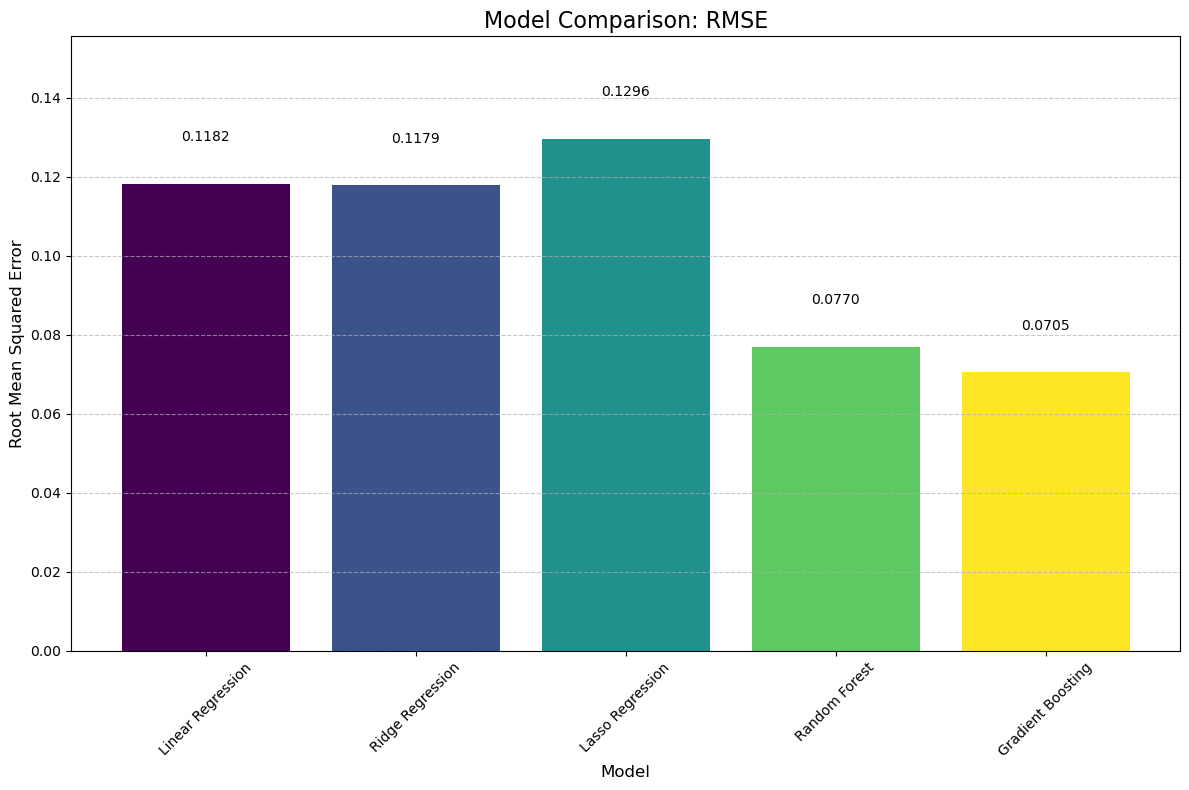

In [263]:
# Plot RMSE for all models with dynamic colors and annotations
plt.figure(figsize=(12, 8))

# Generate dynamic colors using matplotlib
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))

# Create the bar plot manually using matplotlib
bars = plt.bar(
    x=results_df['Model'],
    height=results_df['RMSE'],
    color=colors
)

# Add RMSE values dynamically on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center the text horizontally
        height + 0.01,  # Slightly above the bar
        f"{height:.4f}",  # Format the RMSE value
        ha='center', va='bottom', fontsize=10, color='black'
    )

# Customize the plot
plt.title("Model Comparison: RMSE", fontsize=16)
plt.ylabel("Root Mean Squared Error", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for clarity


# Add extra space above the highest bar
y_max = results_df['RMSE'].max() * 1.2  # Add 20% more space
plt.ylim(0, y_max)

plt.tight_layout()  # Ensure everything fits well in the figure
plt.show()

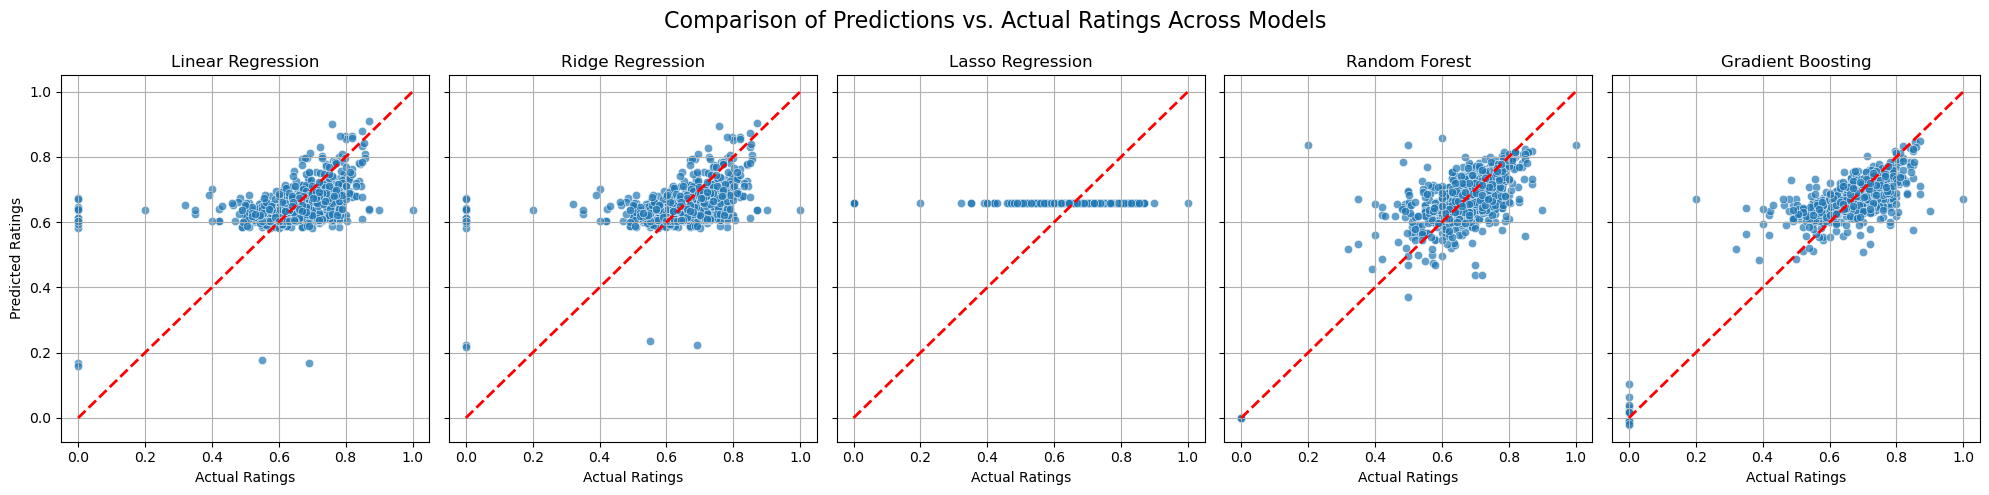

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a grid of subplots
fig, axes = plt.subplots(1, len(models), figsize=(20, 5), sharey=True)

# Create a scatter plot for each model
for ax, (model_name, model) in zip(axes, models.items()):
    # Generate predictions
    y_pred = model.predict(X_test)
    
    # Scatter plot for predictions vs. actuals
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.7)
    
    # Add a perfect fit line
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    
    # Customize each subplot
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Actual Ratings")
    if ax == axes[0]:  # Set y-label only for the first subplot
        ax.set_ylabel("Predicted Ratings")
    ax.grid(True)

# Overall plot customization
fig.suptitle("Comparison of Predictions vs. Actual Ratings Across Models", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Add some space for the title
plt.show()

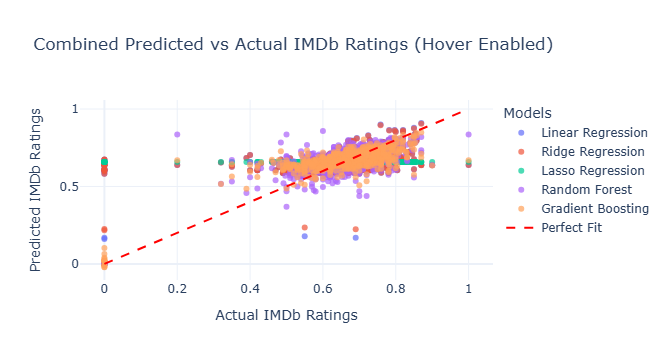

In [229]:
import plotly.graph_objects as go

# Prepare data for hover-enabled scatter plot
fig = go.Figure()

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    fig.add_trace(go.Scatter(
        x=y_test,
        y=y_pred,
        mode='markers',
        name=model_name,
        hovertemplate=(
            f"<b>Model:</b> {model_name}<br>" +
            "<b>Actual Rating:</b> %{x:.2f}<br>" +
            "<b>Predicted Rating:</b> %{y:.2f}<extra></extra>"
        ),
        marker=dict(size=6, opacity=0.7)
    ))

# Add a line for perfect predictions
fig.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Fit',
    line=dict(color='red', dash='dash')
))

# Customize layout
fig.update_layout(
    title="Combined Predicted vs Actual IMDb Ratings (Hover Enabled)",
    xaxis_title="Actual IMDb Ratings",
    yaxis_title="Predicted IMDb Ratings",
    template="plotly_white",
    legend_title="Models"
)

# Show the plot
fig.show()

***Milestone 5: Building a Simple Recommendation System***

In [267]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def movie_recommendation_system():
    # Load the cleaned dataset
    df = pd.read_csv('cleaned_movies_dataset.csv')

    # Combine textual features for recommendations
    df['combined_features'] = df['Genre(s)'] + ' ' + df['Description']

    # Vectorize the textual features
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(df['combined_features'])

    # Compute cosine similarity
    cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

    def recommend_movies(movie_title, num_recommendations=5):
        """
        Recommend movies based on the input title.

        Parameters:
            movie_title (str): Title of the movie to base recommendations on.
            num_recommendations (int): Number of recommendations to return.

        Returns:
            DataFrame: Recommended movie titles, genres, and IMDb ratings.
        """
        if movie_title not in df['Title'].values:
            return f"Movie '{movie_title}' not found in the dataset."

        # Get the index of the movie
        idx = df[df['Title'] == movie_title].index[0]

        # Get similarity scores for the movie
        sim_scores = list(enumerate(cosine_sim[idx]))

        # Sort movies by similarity score
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # Get top recommendations (excluding the input movie itself)
        sim_scores = sim_scores[1:num_recommendations+1]

        # Return movie titles
        movie_indices = [i[0] for i in sim_scores]        
        return df.iloc[movie_indices][['Title', 'Genre(s)', 'IMDb Rating']]
        
    print("Welcome to the Movie Recommendation System!")
    print("Type 'exit' to quit.")
    
    while True:        
        movie_title = input("Enter a movie title from the dataset: ")
        if movie_title.lower() == 'exit':            
            print("Goodbye!")
            break
            
        recommendations = recommend_movies(movie_title, num_recommendations=5)        
        if isinstance(recommendations, str):
            print(recommendations)        
        else:
            print(f"\nRecommendations for '{movie_title}':")            
            print(recommendations.to_string(index=False))
            
# Run the recommendation system
movie_recommendation_system()

Welcome to the Movie Recommendation System!
Type 'exit' to quit.


Enter a movie title from the dataset:  Moana 2



Recommendations for 'Moana 2':
                    Title                                     Genre(s)  IMDb Rating
                    Moana           Adventure, Comedy, Family, Fantasy          0.0
          Run, Tiger Run! Animation, Adventure, Comedy, Action, Family          6.1
An Almost Christmas Story        Animation, Adventure, Fantasy, Family          7.6
     Sonic the Hedgehog 3   Adventure, Comedy, Family, Science Fiction          0.0
                Migration Animation, Action, Adventure, Comedy, Family          7.4


Enter a movie title from the dataset:  Titanic



Recommendations for 'Titanic':
                         Title                             Genre(s)  IMDb Rating
                   Silent Hill                      Horror, Mystery        6.574
                    Titanic II Action, Thriller, Romance, Adventure        5.000
The Last Voyage of the Demeter            Horror, Thriller, Fantasy        6.800
               Vampire Academy              Comedy, Action, Fantasy        6.334
              Someone Like You                       Romance, Drama        6.800


Enter a movie title from the dataset:  Agai salem


Movie 'Agai salem' not found in the dataset.


Enter a movie title from the dataset:  exit


Goodbye!


In [269]:
# Create a sample user-movie rating matrix (use your dataset if it includes user ratings)
data = {
    'User': ['User1', 'User2', 'User3', 'User1', 'User2', 'User3'],
    'Title': ['Inception', 'Inception', 'Avatar', 'Avatar', 'Titanic', 'Titanic'],
    'Rating': [5, 4, 5, 4, 5, 4]
}
ratings_df = pd.DataFrame(data)

# Pivot the table
user_movie_matrix = ratings_df.pivot_table(index='User', columns='Title', values='Rating').fillna(0)

# Compute cosine similarity between users
user_sim = cosine_similarity(user_movie_matrix)

# Function to recommend movies based on user similarity
def recommend_movies_for_user(user_id, num_recommendations=5):
    # Get user's similarity scores
    user_idx = ratings_df['User'].unique().tolist().index(user_id)
    sim_scores = user_sim[user_idx]
    
    # Sort users by similarity scores
    similar_users = [(i, score) for i, score in enumerate(sim_scores) if i != user_idx]
    similar_users = sorted(similar_users, key=lambda x: x[1], reverse=True)
    
    # Get movies rated highly by similar users
    recommended_movies = []
    for similar_user_idx, _ in similar_users:
        similar_user = ratings_df['User'].unique()[similar_user_idx]
        high_rated_movies = ratings_df[(ratings_df['User'] == similar_user) & (ratings_df['Rating'] >= 4)]['Title']
        recommended_movies.extend(high_rated_movies)
        
    # Return unique recommendations
    return list(set(recommended_movies))[:num_recommendations]

# Example usage
print("Recommendations for User1:")
print(recommend_movies_for_user('User1', 5))

Recommendations for User1:
['Avatar', 'Titanic', 'Inception']


***Milestone 6: Data Storage and Access***

In [321]:
# Store the cleaned dataset and user rating data in a database 
import sqlite3
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("cleaned_movies_dataset.csv")

# Connect to SQLite database (or create it if it doesn't exist)
conn = sqlite3.connect("movies.db")
cursor = conn.cursor()

# Create the movies table with an `id` column as the primary key
cursor.execute("""
    CREATE TABLE IF NOT EXISTS movies (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        Title TEXT,
        "Genre(s)" TEXT,
        "Release Year" REAL,
        "IMDb Rating" REAL,
        "User Votes" INTEGER,
        Description TEXT,
        "Poster URL" TEXT,
        Genre TEXT,
        "IMDb Rating Norm" REAL,
        "User Votes Norm" REAL,
        "Release Year Norm" REAL,
        Genre_transformed INTEGER
    )
""")
conn.commit()

# Remove `id` column from the DataFrame if it exists
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Insert data into the movies table
df.to_sql("movies", conn, if_exists="append", index=False)

# Verify the data in the table
cursor.execute("SELECT COUNT(*) FROM movies")
print("Number of records in the movies table:", cursor.fetchone()[0])

# Verify schema
cursor.execute("PRAGMA table_info(movies)")
print("Table structure:", cursor.fetchall())

conn.close()

Number of records in the movies table: 15311
Table structure: [(0, 'id', 'INTEGER', 0, None, 1), (1, 'Title', 'TEXT', 0, None, 0), (2, 'Genre(s)', 'TEXT', 0, None, 0), (3, 'Release Year', 'REAL', 0, None, 0), (4, 'IMDb Rating', 'REAL', 0, None, 0), (5, 'User Votes', 'INTEGER', 0, None, 0), (6, 'Description', 'TEXT', 0, None, 0), (7, 'Poster URL', 'TEXT', 0, None, 0), (8, 'Genre', 'TEXT', 0, None, 0), (9, 'IMDb Rating Norm', 'REAL', 0, None, 0), (10, 'User Votes Norm', 'REAL', 0, None, 0), (11, 'Release Year Norm', 'REAL', 0, None, 0), (12, 'Genre_transformed', 'INTEGER', 0, None, 0)]


In [323]:
conn = sqlite3.connect("movies.db")
cursor = conn.cursor()

# Check the table structure
cursor.execute("PRAGMA table_info(movies)")
columns = cursor.fetchall()
print(columns)

# Fetch the first 10 records to verify
cursor.execute("SELECT * FROM movies LIMIT 10")
records = cursor.fetchall()
print(records)

conn.close()

[(0, 'id', 'INTEGER', 0, None, 1), (1, 'Title', 'TEXT', 0, None, 0), (2, 'Genre(s)', 'TEXT', 0, None, 0), (3, 'Release Year', 'REAL', 0, None, 0), (4, 'IMDb Rating', 'REAL', 0, None, 0), (5, 'User Votes', 'INTEGER', 0, None, 0), (6, 'Description', 'TEXT', 0, None, 0), (7, 'Poster URL', 'TEXT', 0, None, 0), (8, 'Genre', 'TEXT', 0, None, 0), (9, 'IMDb Rating Norm', 'REAL', 0, None, 0), (10, 'User Votes Norm', 'REAL', 0, None, 0), (11, 'Release Year Norm', 'REAL', 0, None, 0), (12, 'Genre_transformed', 'INTEGER', 0, None, 0)]
[(1, 'Venom: The Last Dance', 'Action, Science Fiction, Adventure', 2024.0, 8.9, 1106, "Eddie and Venom are on the run. Hunted by both of their worlds and with the net closing in, the duo are forced into a devastating decision that will bring the curtains down on Venom and Eddie's last dance.", 'https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBVpSxyimorCQykC.jpg', 'Action', 0.66, 0.0301897092943906, 0.9716981132075482, 0), (3, 'Elevation', 'Action, Science Fiction, Thril

In [325]:
# Implement basic CRUD operations 
import sqlite3

# Connect to the database
conn = sqlite3.connect("movies.db")
cursor = conn.cursor()

# Function to fetch all movies
def fetch_movies(limit=10):
    query = "SELECT id, Title, 'Genre(s)', 'Release Year', 'IMDb Rating', 'User Votes', Description FROM movies LIMIT ?"
    cursor.execute(query, (limit,))
    results = cursor.fetchall()
    return results

# Function to update a movie rating
def update_rating(movie_id, new_rating):
    query = "UPDATE movies SET 'IMDb Rating' = ? WHERE id = ?"
    cursor.execute(query, (new_rating, movie_id))
    conn.commit()
    print(f"Updated IMDb rating for movie ID {movie_id} to {new_rating}.")

# Function to delete a movie by ID
def delete_movie(movie_id):
    query = "DELETE FROM movies WHERE id = ?"
    cursor.execute(query, (movie_id,))
    conn.commit()
    print(f"Deleted movie with ID {movie_id}.")

# Test CRUD Operations
print("First 10 Movies:")
for movie in fetch_movies(10):
    print(movie)

# Example: Update rating
update_rating(1, 8.9)

# Example: Delete a movie
delete_movie(2)

# Verify the changes
print("First 10 Movies After Update and Delete:")
for movie in fetch_movies(10):
    print(movie)

conn.close()

First 10 Movies:
(1, 'Venom: The Last Dance', 'Genre(s)', 'Release Year', 'IMDb Rating', 'User Votes', "Eddie and Venom are on the run. Hunted by both of their worlds and with the net closing in, the duo are forced into a devastating decision that will bring the curtains down on Venom and Eddie's last dance.")
(3, 'Elevation', 'Genre(s)', 'Release Year', 'IMDb Rating', 'User Votes', 'A single father and two women venture from the safety of their homes to face monstrous creatures to save the life of a young boy.')
(4, 'Absolution', 'Genre(s)', 'Release Year', 'IMDb Rating', 'User Votes', 'An aging ex-boxer gangster working as muscle for a Boston crime boss receives an upsetting diagnosis.  Despite a faltering memory, he attempts to rectify the sins of his past and reconnect with his estranged children. He is determined to leave a positive legacy for his grandson, but the criminal underworld isn’t done with him and won’t loosen their grip willingly.')
(5, 'Watchmen: Chapter II', 'Genre(s

In [329]:
# Function to get recommendations based on genre and IMDb rating
# Enablequerying of data to get recommendations from the database.

def get_recommendations(genre, min_rating=7.0, limit=5):
    query = """
    SELECT Title, "Genre(s)", "IMDb Rating", Description
    FROM movies
    WHERE "Genre(s)" LIKE ? AND "IMDb Rating" >= ?
    ORDER BY "IMDb Rating" DESC
    LIMIT ?
    """
    cursor.execute(query, (f"%{genre}%", min_rating, limit))
    results = cursor.fetchall()
    return results

# Connect to the database
conn = sqlite3.connect("movies.db")
cursor = conn.cursor()

# Example: Get recommendations
genre = "Action"  # Specify the genre
min_rating = 8.0  # Specify the minimum rating threshold
recommendations = get_recommendations(genre, min_rating, limit=5)

print(f"Top 5 Recommendations for Genre '{genre}' with IMDb Rating >= {min_rating}:")
for rec in recommendations:
    print(rec)

conn.close()

Top 5 Recommendations for Genre 'Action' with IMDb Rating >= 8.0:
('UFC 310: Pantoja vs. Asakura', 'Action', 10.0, 'UFC 310 was a mixed martial arts event produced by the Ultimate Fighting Championship that took place on December 7, 2024, at the T-Mobile Arena in Paradise, Nevada, part of the Las Vegas Valley, United States. A UFC Flyweight Championship bout between current champion Alexandre Pantoja and former two-time Rizin Bantamweight Champion (also promotional newcomer) Kai Asakura was the main event.')
('UFC 310: Pantoja vs. Asakura', 'Action', 10.0, 'UFC 310 was a mixed martial arts event produced by the Ultimate Fighting Championship that took place on December 7, 2024, at the T-Mobile Arena in Paradise, Nevada, part of the Las Vegas Valley, United States. A UFC Flyweight Championship bout between current champion Alexandre Pantoja and former two-time Rizin Bantamweight Champion (also promotional newcomer) Kai Asakura was the main event.')
('UFC 310: Pantoja vs. Asakura', 'Acti